Text(0, 0.5, 'Doppler b parameter (km/s)')

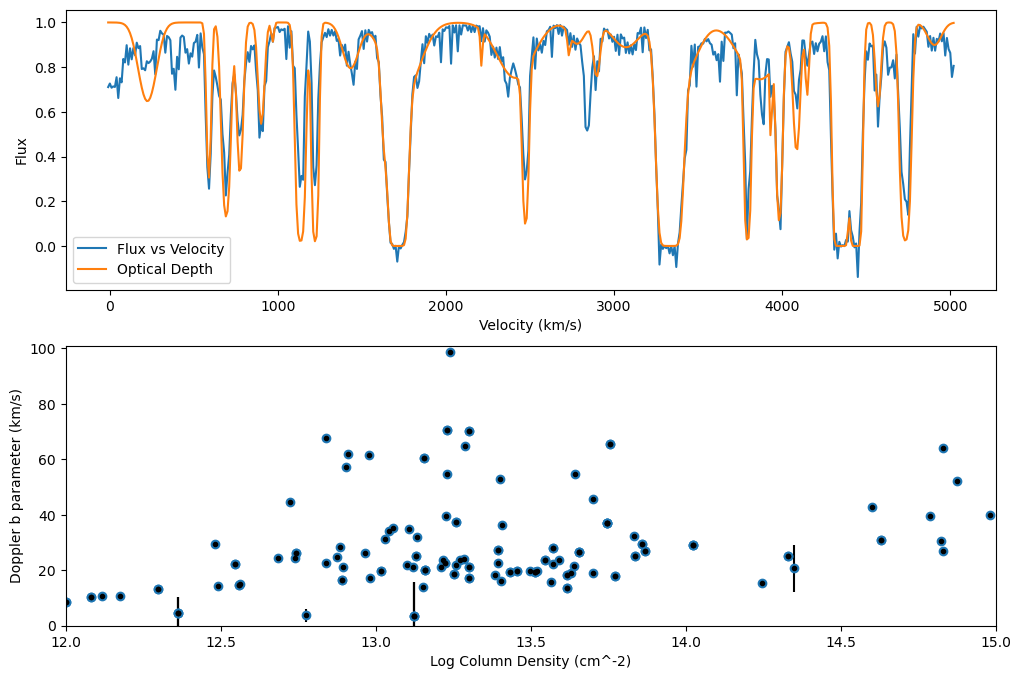

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats
import math

filename = "los-Copy1.00000.fHI"
vel1,flux1 = np.loadtxt(filename,delimiter = ',', unpack = True, skiprows = 2)
vel = []
flux = []
for i in range(504):
    vel.append(vel1[i])
    flux.append(flux1[i])
fig, axs = plt.subplots(2,figsize = (12,8))
axs[0].plot(vel, flux, label = 'Flux vs Velocity')
axs[0].set_ylabel('Flux')
axs[0].set_xlabel('Velocity (km/s)')

filename1 = "los.00000 (1).bN"
WL, ro, b, dWL, dro, db, chisq = np.loadtxt(filename1, unpack = True)
filename2 = "los-Copy1.00001.bN"
WL2, ro2, b2, dWL2, dro2, db2, chisq2 = np.loadtxt(filename2, unpack = True)
filename3 = "los-Copy1.00002.bN"
WL3, ro3, b3, dWL3, dro3, db3, chisq3 = np.loadtxt(filename3, unpack = True)
filename4 = "los-Copy1.00003.bN"
WL4, ro4, b4, dWL4, dro4, db4, chisq4 = np.loadtxt(filename4, unpack = True)

WL1 = []
ro1 = []
dWL1 = []
dro1 = []
db1 = []
b1 = []
chisq1 = []

for i in range(len(chisq)):
    if 0.1 < chisq[i] < 3  and 8 < b[i] < 100 and 12 < ro[i] < 15 and np.isfinite(chisq[i]) and np.isfinite(db[i]) and np.isfinite(dro[i]) and np.isfinite(ro[i]) and np.isfinite(b[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])   
for i in range(len(chisq2)):
    if 0.1 < chisq2[i] < 3  and 8 < b2[i] < 100 and 12 < ro2[i] < 15 and np.isfinite(chisq2[i]) and np.isfinite(db2[i]) and np.isfinite(dro2[i]) and np.isfinite(ro2[i]) and np.isfinite(b2[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])      
for i in range(len(chisq3)):
    if 0.1 < chisq3[i] < 3  and 8 < b3[i] < 100 and 12 < ro3[i] < 15 and np.isfinite(chisq3[i]) and np.isfinite(db3[i]) and np.isfinite(dro3[i]) and np.isfinite(ro3[i]) and np.isfinite(b3[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])   
for i in range(len(chisq4)):
    if 0.1 < chisq4[i] < 3  and 8 < b4[i] < 100 and 12 < ro4[i] < 15 and np.isfinite(chisq4[i]) and np.isfinite(db4[i]) and np.isfinite(dro4[i]) and np.isfinite(ro4[i]) and np.isfinite(b4[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])
Cm = 4.5e-18
c = 3e5
vi_lst = []
for i in WL1:
    vi = 3e5 * ((i / (4*1216)) - 1)
    vi_lst.append(vi)   
def tfit(num):
    sum1 = 0
    for i in range(len(WL1)):
        A = (10**ro1[i] * c) / (b1[i] * np.sqrt(np.pi))
        B = ((num - vi_lst[i]) ** 2) / (b1[i] ** 2)
        sum1 += A * np.exp(-B)
    val = Cm * sum1
    return val  

axs[0].plot(vel,np.exp(-tfit(vel)), label = 'Optical Depth')
axs[0].legend()

axs[1].errorbar(ro1, b1, dro1, fmt = 'k.', label = 'Errors',capsize = 0)
axs[1].plot(ro1, b1, 'o')
axs[1].set_xlim(12,15)
axs[1].set_ylim(0,101)
axs[1].set_xlabel('Log Column Density (cm^-2)')
axs[1].set_ylabel('Doppler b parameter (km/s)')


In [25]:
# Part B
import scipy
# Conversion of Log10(N) to Ln(N)
x = np.array(ro1) * np.log(10)
dx = np.array(dro1) * np.log(10)
N0 = 3e13
xmax = np.log(1.0e15)
xmin = np.log(1.0e12)

def ifun2(x,b,t,bi,xi,dbi,dxi):
    bt = t[0]* ((np.exp(x)/N0)**t[1])
    bstar = bt* (t[3]/t[4])**(1/t[4])
    p = (t[4] * np.exp(x * t[2]) * ((bstar/b)**t[3]) * np.exp(-(bstar/b)**t[4]) ) / ( bstar * scipy.special.gamma((t[3]-1)/t[4]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num
             
def llfun2(t):
    ret = 0
    if(t[2] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[2]/(np.exp(t[2]*xmax)-np.exp(t[2]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5*db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun2,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

't = [b0, β, α, ϕ, Φ]'
t0 = [15, 0.2, 0.2, 3, 3]

print(llfun2(t0))

[15, 0.2, 0.2, 3, 3] 1118.2576839505243
1118.2576839505243


In [26]:
# Part C
from timeit import default_timer as timer # time all methods
start_time = timer()
't = [b0, β, α, ϕ, Φ]'
t0 = [23.10359169,  0.2222904,  -0.05935949,  3.82093482,  2.68905924]
t0 = np.array(t0)
bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([3, -1, -1, 2, 0.5])
bounds0.ub = np.array([50, 2,  1, 8, 6])
res = scipy.optimize.minimize(llfun2, t0, bounds = bounds0)
print("optimization time=%g"%(timer()-start_time))
print(res)
# [18.97484175  0.1629619  -0.05780503  2.67453555  4.79581989] 1069.1219400372504

[23.10359169  0.2222904  -0.05935949  3.82093482  2.68905924] 1089.5635653000093
[23.1035917   0.2222904  -0.05935949  3.82093482  2.68905924] 1089.563565360595
[23.10359169  0.22229041 -0.05935949  3.82093482  2.68905924] 1089.563566697513
[23.10359169  0.2222904  -0.05935948  3.82093482  2.68905924] 1089.5635652293777
[23.10359169  0.2222904  -0.05935949  3.82093483  2.68905924] 1089.5635654208893
[23.10359169  0.2222904  -0.05935949  3.82093482  2.68905925] 1089.563565392352
[17.04501597 -1.          1.          2.          0.5       ] 1747.6896802599395
[17.04501598 -1.          1.          2.          0.5       ] 1747.689680373316
[17.04501597 -0.99999999  1.          2.          0.5       ] 1747.6896760843604
[17.04501597 -1.          0.99999999  2.          0.5       ] 1747.6896763411708
[17.04501597 -1.          1.          2.00000001  0.5       ] 1747.6896801181583
[17.04501597 -1.          1.          2.          0.50000001] 1747.6896827487888
[2.27204560e+01 1.44994493e-01 7

In [29]:
't = [b0, β, α, ϕ, Φ]'
b0_star = res.x[0]
beta_star = res.x[1]
B_pair = (b0_star, beta_star)

bb = 1 + 1.4*beta_star
G = ((3.634 * beta_star) / bb) + 1
T = (( (b0_star / 13) ** 2) * (bb / 1 + 0.128*beta_star) ** beta_star ) ** (1 / bb)
C_pair = (T, G - 1 )
print(B_pair)
print(C_pair)

(18.974841752851326, 0.16296189976629596)
(1.9066216944456413, 0.48219285464529626)


[-0.05780503  2.67453555  4.79581988] 1094.3048571385748
[-0.05780502  2.67453555  4.79581988] 1094.304857188373
[-0.05780503  2.67453556  4.79581988] 1094.304857305144
[-0.05780503  2.67453555  4.79581989] 1094.3048571869858
[-1.   2.   0.5] 1448.1575610042973
[-0.99999999  2.          0.5       ] 1448.1575579380851
[-1.          2.00000001  0.5       ] 1448.1575598832048
[-1.          2.          0.50000001] 1448.157558509323
[-0.24109218  2.54331674  3.96014509] 1098.2402637981495
[-0.24109217  2.54331674  3.96014509] 1098.240262862579
[-0.24109218  2.54331675  3.96014509] 1098.2402638609951
[-0.24109218  2.54331674  3.9601451 ] 1098.2402638184096
[-0.11583865  2.63298816  4.53122286] 1093.1765773097973
[-0.11583864  2.63298816  4.53122286] 1093.176577034365
[-0.11583865  2.63298817  4.53122286] 1093.176577444991
[-0.11583865  2.63298816  4.53122287] 1093.176577349108
[-0.10384369  2.57124788  4.3116634 ] 1091.4123686400062
[-0.10384368  2.57124788  4.3116634 ] 1091.4123684321817
[-

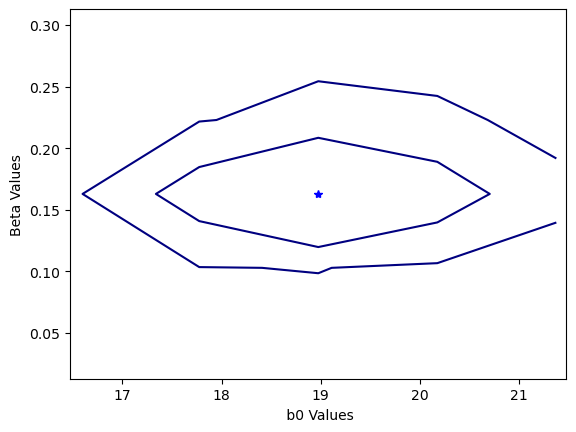

In [31]:
# Part D

def ifun(x,b,t,B0,BE,bi,xi,dbi,dxi):
    bt = B0 * ((np.exp(x)/N0) ** BE)
    bstar = bt * (t[1]/t[2])**(1/t[2])
    p = (t[2] * np.exp(x * t[0]) * ((bstar/b)**t[1]) * np.exp(-(bstar/b)**t[2]) ) / ( bstar * scipy.special.gamma((t[1]-1)/t[2]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num           
def llfun(t,B0,BE):
    ret = 0
    if(t[0] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[0]/(np.exp(t[0]*xmax)-np.exp(t[0]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5 * db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,B0,BE,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

b01 =  res.x[0]
db0 = 4.8
b11 = res.x[1]
db11 = 0.24
N = 4
tv = [1,1]
#t = [α, ϕ, Φ]
p1 = [res.x[2], res.x[3], res.x[4]]

b0vals = np.zeros(( N + 1,N + 1))
Bvals = np.zeros((  N + 1,N + 1))
pvals = np.zeros((  N + 1,N + 1))
bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1, 2, 0.5])
bounds0.ub = np.array([1, 8, 6])
for i1 in range(N + 1):
    tv[0] = b01 + (db0/N) * (i1 - N/2)
    for i0 in range(N + 1):
        tv[1] = b11  + (db11/N) * (i0 - N/2)
        b0vals[i0,i1] = tv[0]
        Bvals[i0,i1] =  tv[1] 
        resmin = scipy.optimize.minimize(llfun, p1, args = (tv[0],tv[1]), bounds = bounds0)
        chisqq = resmin.fun - res.fun
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(chisqq, 2)
        print('5- parameter Min Liklihood value',res.fun)
        print('3-parameter Likelihood Value',resmin.fun)
        print('Chisquare value',chisqq)
        print('B0 Values',b0vals)
        print('Beta Values',Bvals)
        print('P Values',pvals)
        
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"b*")
        

[[0.14726599 0.14726599 0.14726599 0.14726599 0.14726599]
 [0.32702411 0.32702411 0.32702411 0.32702411 0.32702411]
 [0.48219285 0.48219285 0.48219285 0.48219285 0.48219285]
 [0.61749465 0.61749465 0.61749465 0.61749465 0.61749465]
 [0.73651542 0.73651542 0.73651542 0.73651542 0.73651542]]
[[1.58547521 1.8089546  2.04622379 2.29718085 2.56173079]
 [1.54930832 1.75065914 1.96244444 2.1844937  2.41664944]
 [1.52977122 1.71419765 1.90662169 2.10685138 2.31471074]
 [1.52212385 1.69324479 1.87053377 2.05380183 2.24287689]
 [1.52323496 1.68365384 1.84882882 2.0185866  2.19277029]]
(1.9066216944456413, 0.48219285464529626)


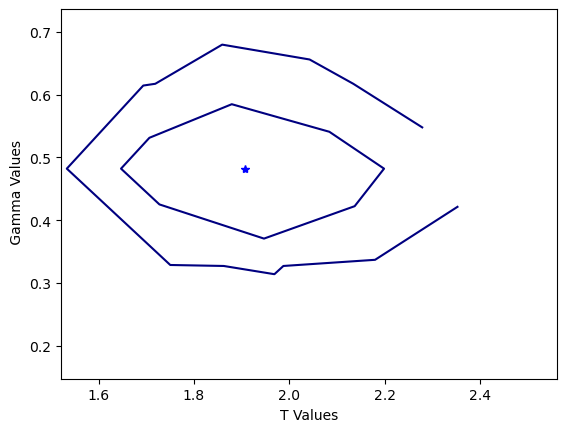

In [32]:
Gvals = np.zeros(( N + 1,N + 1))
Tvals = np.zeros((  N + 1,N + 1))
for i1 in range(N+1):
    for i2 in range (N+1):
        bb = 1 + 1.4*Bvals[i1][i2]
        G = ((3.634 * Bvals[i1][i2]) / bb) 
        T = (( (b0vals[i1][i2] / 13) ** 2) * (bb / 1 + 0.128* Bvals[i1][i2]) ** Bvals[i1][i2] ) ** (1 / bb)
        Gvals[i1][i2] = G 
        Tvals[i1][i2] = T
print(Gvals)
print(Tvals)
print(C_pair)
fig, ax = plt.subplots()
ax.set_xlabel("T Values")
ax.set_ylabel(" Gamma Values")
ax.contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax.plot([C_pair[0]],[C_pair[1]],"b*")

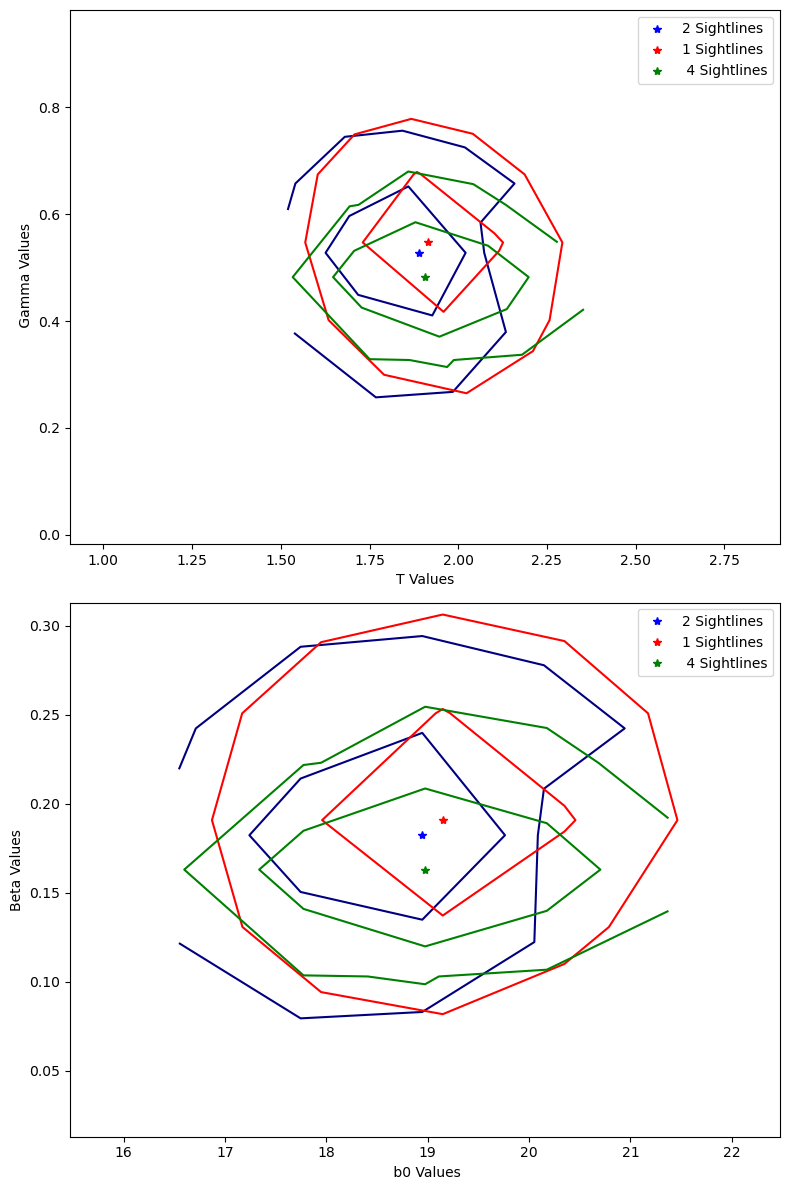

In [39]:
fig, ax = plt.subplots(2,figsize = (8,12))

'''
Output from using 2 sightlines
'''
B0vals2  = np.array([[16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578]] )
Bvals2 = np.array([[0.06226794, 0.06226794, 0.06226794, 0.06226794, 0.06226794],
 [0.12226794, 0.12226794, 0.12226794, 0.12226794, 0.12226794],
 [0.18226794, 0.18226794, 0.18226794, 0.18226794, 0.18226794],
 [0.24226794, 0.24226794, 0.24226794, 0.24226794, 0.24226794],
 [0.30226794, 0.30226794, 0.30226794, 0.30226794, 0.30226794]] )
pvals2 =  np.array( [[2.50602346e-03, 3.56972911e-03, 2.44510718e-03, 8.90213359e-04,
  1.98046837e-04],
 [5.04530756e-02, 1.65883590e-01, 1.39969513e-01, 4.22897286e-02,
  7.07767581e-03],
 [8.00392365e-02, 4.94473462e-01, 1.00000000e+00, 4.95747443e-08,
  2.55481295e-02],
 [3.13654097e-02, 1.65609935e-01, 2.90184427e-01, 1.14915591e-01,
  1.71381509e-02],
 [5.02219333e-03, 1.42554236e-02, 1.22828612e-02, 5.06988436e-03,
  1.28296513e-03]] )
Gvals2 = np.array([[0.20813729, 0.20813729, 0.20813729, 0.20813729, 0.20813729],
 [0.37938109, 0.37938109, 0.37938109, 0.37938109, 0.37938109],
 [0.5277046,  0.5277046,  0.5277046,  0.5277046,  0.5277046 ],
 [0.65742088, 0.65742088, 0.65742088, 0.65742088, 0.65742088],
 [0.77182469, 0.77182469, 0.77182469,0.77182469, 0.77182469]])
Tvals2 = np.array([[1.56670892, 1.78207085, 2.01001938, 2.25042302, 2.50315963],
 [1.53698777, 1.73218841, 1.93696189, 2.1511267,  2.37451561],
 [1.52204116, 1.7016732,  1.88866359, 2.08281896, 2.28396247],
 [1.5177683,  1.68506329, 1.8580379,  2.03650676, 2.22030145],
 [1.52142596, 1.67873168, 1.84041091, 2.00629656, 2.17623761]])
b2 = (18.94655780286924, 0.18226793763492896)
C2 = (1.8886635893315167, 0.527704603659952)

'''
Output from using 1 sightline
'''
B0Values1 = np.array([[16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987]])
BetaValues1 = np.array( [[0.07073621, 0.07073621, 0.07073621, 0.07073621, 0.07073621],
 [0.13073621, 0.13073621, 0.13073621, 0.13073621, 0.13073621],
 [0.19073621, 0.19073621, 0.19073621, 0.19073621, 0.19073621],
 [0.25073621, 0.25073621, 0.25073621, 0.25073621, 0.25073621],
 [0.31073621, 0.31073621, 0.31073621, 0.31073621, 0.31073621]] )
Gvals1 = np.array( [[0.23389283, 0.23389283, 0.23389283, 0.23389283, 0.23389283],
 [0.40159177, 0.40159177, 0.40159177, 0.40159177, 0.40159177],
 [0.54705494, 0.54705494, 0.54705494, 0.54705494, 0.54705494],
 [0.67442983, 0.67442983, 0.67442983, 0.67442983, 0.67442983],
 [0.78689285, 0.78689285, 0.78689285, 0.78689285, 0.78689285]] )          
Tvals1 = np.array([[1.59629952, 1.81051594, 2.03680641, 2.27503082, 2.52505906],
 [1.56591502, 1.76024488, 1.96376184, 2.17628359, 2.39764221],
 [1.55029891, 1.72922753, 1.91521587, 2.10807374, 2.30762725],
 [1.54538683, 1.71208193, 1.88422045, 2.06162218, 2.24412334],
 [1.54844917, 1.70521918, 1.86617294, 2.0311493, 2.20000257]])
pvals1= np.array( [[1.35749539e-03, 5.92640155e-03, 7.47914884e-03, 2.39544084e-03,
  2.90786573e-04],
 [1.23856635e-02, 1.18731893e-01, 2.38400922e-01, 7.51428450e-02,
  6.40703939e-03],
 [1.96381408e-02, 3.14378214e-01, 1.00000000e+00, 3.49201832e-01,
  2.70362876e-02],
 [1.10565294e-02, 1.21844955e-01, 3.32304352e-01, 1.31630517e-01,
  1.28160632e-02],
 [2.43704504e-03, 1.39296238e-02, 2.69138786e-02, 1.08970838e-02,
  1.41791830e-03]] )
C1 = (1.9152158659599539, 0.5470549358761017)

ax[0].set_xlabel("T Values")
ax[0].set_ylabel(" Gamma Values")
ax[0].set_xlim(C_pair[0] - 1, C_pair[0]+1)
ax[0].set_ylim(C_pair[1] - 0.5,C_pair[1]+0.5)
ax[0].contour(Tvals2, Gvals2, pvals2, levels=[0.05, 0.32], colors = "#000080")
ax[0].plot([C2[0]],[C2[1]],"b*")
ax[0].contour(Tvals1, Gvals1, pvals1, levels=[0.05, 0.32], colors = "r")
ax[0].plot([C1[0]],[C1[1]],"r*")
ax[0].contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "g")
ax[0].plot([C_pair[0]],[C_pair[1]],"g*")
ax[0].legend(['2 Sightlines','1 Sightlines',' 4 Sightlines'])

ax[1].set_ylabel("Beta Values")
ax[1].set_xlabel(" b0 Values")
ax[1].set_xlim(res.x[0]-3.5,res.x[0]+3.5)
ax[1].set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax[1].contour(B0vals2, Bvals2, pvals2, levels=[0.05,0.32], colors = "#000080")
ax[1].plot([b2[0]],[b2[1]],"b*")
ax[1].contour(B0Values1, BetaValues1, pvals1, levels=[0.05,0.32],colors = "r")
ax[1].plot(19.14870986832592,0.19073621276111663,"r*")
ax[1].contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "g")
ax[1].plot([res.x[0]],[res.x[1]],"g*")
ax[1].legend(['2 Sightlines','1 Sightlines',' 4 Sightlines'])

fig.tight_layout()
plt.savefig("ASTR 4-2-1", dpi=300)